# **WARNING**

**THIS NOTEBOOK RUNS THE MODELS.**

**DO NOT 'RUN ALL' UNLESS YOU ARE READY FOR LONG RUN TIMES AND PLEASE DO NOT OVERWRITE MODEL DATA UNLESS EXPERIMENTING**

# Imports

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Biggest Problem

How to handle so many categories...

- have routes instead of each station being separate

- lower weather data to a normalized vector of how likely it is to cause a delay

- remove delay types and have the models predict delays based off of past data and weather correlations

# Model Ideas

- XGBoost
    - Simple, lightweight, fast

- XGBoost Ensemble
    - Since it's so fast we train 10-50 different XGB and have them "vote"

- MLP
    - Probably not gonna work very well

- GNN
    - The libraries for this are a bit difficult to work with
    - Best current option for handling so many diminsions

# Import/Prepare Data

In [181]:
#TODO
# Data things from data/processed
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from src.data_processing import merged_dataset

df = merged_dataset()
print(df.columns)
print(df.dtypes)

Index(['train', 'depart_station', 'arrive_station', 'minutes_late', 'DATE',
       'PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN', 'PRCP_TOTAL', 'TAVG'],
      dtype='object')
train             string[python]
depart_station          category
arrive_station          category
minutes_late             float32
DATE              datetime64[ns]
PRCP                     float32
SNOW                     float32
SNWD                     float32
TMAX                     float32
TMIN                     float32
PRCP_TOTAL               float32
TAVG                     float32
dtype: object


In [147]:
df_training = df.copy()

# Ensure datetime, sort chronologically
df_training["DATE"] = pd.to_datetime(df_training["DATE"])
df_training = df_training.sort_values("DATE")

# Drop rows with missing target
df_training = df_training.dropna(subset=["minutes_late"])

# Reset index for safety
df_training = df_training.reset_index(drop=True)

# Station pair feature
df_training["station_pair"] = (
    df_training["depart_station"].astype(str)
    + "→"
    + df_training["arrive_station"].astype(str)
)

# Time-based features
df_training["year"]  = df_training["DATE"].dt.year
df_training["month"] = df_training["DATE"].dt.month
df_training["day"]   = df_training["DATE"].dt.day
df_training["dow"]   = df_training["DATE"].dt.dayofweek

y = df_training["minutes_late"]
X = df_training.drop(columns=["minutes_late"])

print(f"Station Pairs:", df_training["station_pair"].value_counts(), df_training["station_pair"].describe(), df_training["station_pair"].nunique())
print(f"Depart Stations:", df_training["depart_station"].value_counts(), df_training["depart_station"].describe(), df_training["depart_station"].nunique())
print(f"Arrive Stations:", df_training["arrive_station"].value_counts(), df_training["arrive_station"].describe(), df_training["arrive_station"].nunique())
print(f"Trains:", df_training["train"].value_counts(), df_training["train"].describe(), df_training["train"].nunique())

Station Pairs: station_pair
Babylon→NY Penn Station          18845
Ronkonkoma→NY Penn Station       14389
NY Penn Station→Babylon          14305
NY Penn Station→Huntington       14157
Huntington→NY Penn Station       12352
                                 ...  
Flatbush Avenue→Valley Stream        1
Ronkonkoma→Elmont-UBS Arena          1
Farmingdale→Elmont-UBS Arena         1
Garden City→Grand Central            1
Grand Central→Garden City            1
Name: count, Length: 329, dtype: int64 count                      229877
unique                        329
top       Babylon→NY Penn Station
freq                        18845
Name: station_pair, dtype: object 329
Depart Stations: depart_station
NY Penn Station    65434
Babylon            25313
Huntington         17890
Ronkonkoma         17151
Jamaica            12877
                   ...  
Garden City            2
Storage Yard           2
Seaford                2
East Hampton           1
Woodside               1
Name: count, Length: 67

In [148]:
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test  = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test  = y.iloc[split_idx:].copy()

# Save test dates for plotting
dates_test = X_test["DATE"].reset_index(drop=True)

# Drop DATE before training
X_train.drop(columns=["DATE"], inplace=True)
X_test.drop(columns=["DATE"], inplace=True)

cat_cols = ["train", "depart_station", "arrive_station", "station_pair"]

for col in cat_cols:
    means = y_train.groupby(X_train[col]).mean()

    X_train[col + "_mean"] = X_train[col].map(means)
    X_test[col + "_mean"]  = X_test[col].map(means)

# Drop original categorical columns
X_train.drop(columns=cat_cols, inplace=True)
X_test.drop(columns=cat_cols, inplace=True)

# Fill unseen categories with global mean
global_mean = y_train.mean()
X_train.fillna(global_mean, inplace=True)
X_test.fillna(global_mean, inplace=True)

y_train = y_train.clip(upper=y_train.quantile(0.99))

# Reset indices to ensure perfect alignment
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)

print(X_train.head())

   PRCP  SNOW  ...  arrive_station_mean  station_pair_mean
0  0.24   5.2  ...            11.625776          12.025818
1  0.24   5.2  ...            12.375364          12.137803
2  0.24   5.2  ...            11.625776           9.744316
3  0.24   5.2  ...            12.375364          12.137803
4  0.24   5.2  ...            11.625776          11.027278

[5 rows x 15 columns]


C:\Users\skylerturner\AppData\Local\Temp\ipykernel_6356\2534555264.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = y_train.groupby(X_train[col]).mean()
C:\Users\skylerturner\AppData\Local\Temp\ipykernel_6356\2534555264.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = y_train.groupby(X_train[col]).mean()


In [149]:
# Verify that indexes are looking the same, which they are
y_train.head()

0     9.0
1    10.0
2    19.0
3    10.0
4     9.0
Name: minutes_late, dtype: float32

# Random Forest

In [150]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions and evaluate
predictions_rf = rf_model.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions_rf):.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, predictions_rf)):.2f} minutes")
print(f"R-squared Score: {r2_score(y_test, predictions_rf):.2f}")
mape = mean_absolute_percentage_error(y_test, predictions_rf) * 100
print(f"MAPE: {mape:.2f}%")

Mean Absolute Error: 6.80 minutes
Root Mean Squared Error (RMSE): 10.02 minutes
R-squared Score: -0.13
MAPE: 69.92%


# XGB First

In [151]:
#TODO
# XGB Code
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

xgb_model.fit(X_train, y_train)

predictions_xgb = xgb_model.predict(X_test)

print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions_xgb):.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, predictions_xgb)):.2f} minutes")
print(f"R-squared Score: {r2_score(y_test, predictions_xgb):.2f}")
mape = mean_absolute_percentage_error(y_test, predictions_xgb) * 100
print(f"MAPE: {mape:.2f}%")

Mean Absolute Error: 5.66 minutes
Root Mean Squared Error (RMSE): 9.48 minutes
R-squared Score: -0.01
MAPE: 52.94%


In [152]:
# Convert predictions and y_test to Series
y_test_series = pd.Series(y_test)
pred_rf_series = pd.Series(predictions_rf)
pred_xgb_series = pd.Series(predictions_xgb)

# Compute averages
actual_avg = y_test_series.mean()
rf_avg = pred_rf_series.mean()
xgb_avg = pred_xgb_series.mean()

print(f"Average Actual Delay: {actual_avg:.2f} minutes")
print(f"Average RF Predicted Delay: {rf_avg:.2f} minutes")
print(f"Average XGB Predicted Delay: {xgb_avg:.2f} minutes")

Average Actual Delay: 11.52 minutes
Average RF Predicted Delay: 14.26 minutes
Average XGB Predicted Delay: 12.33 minutes


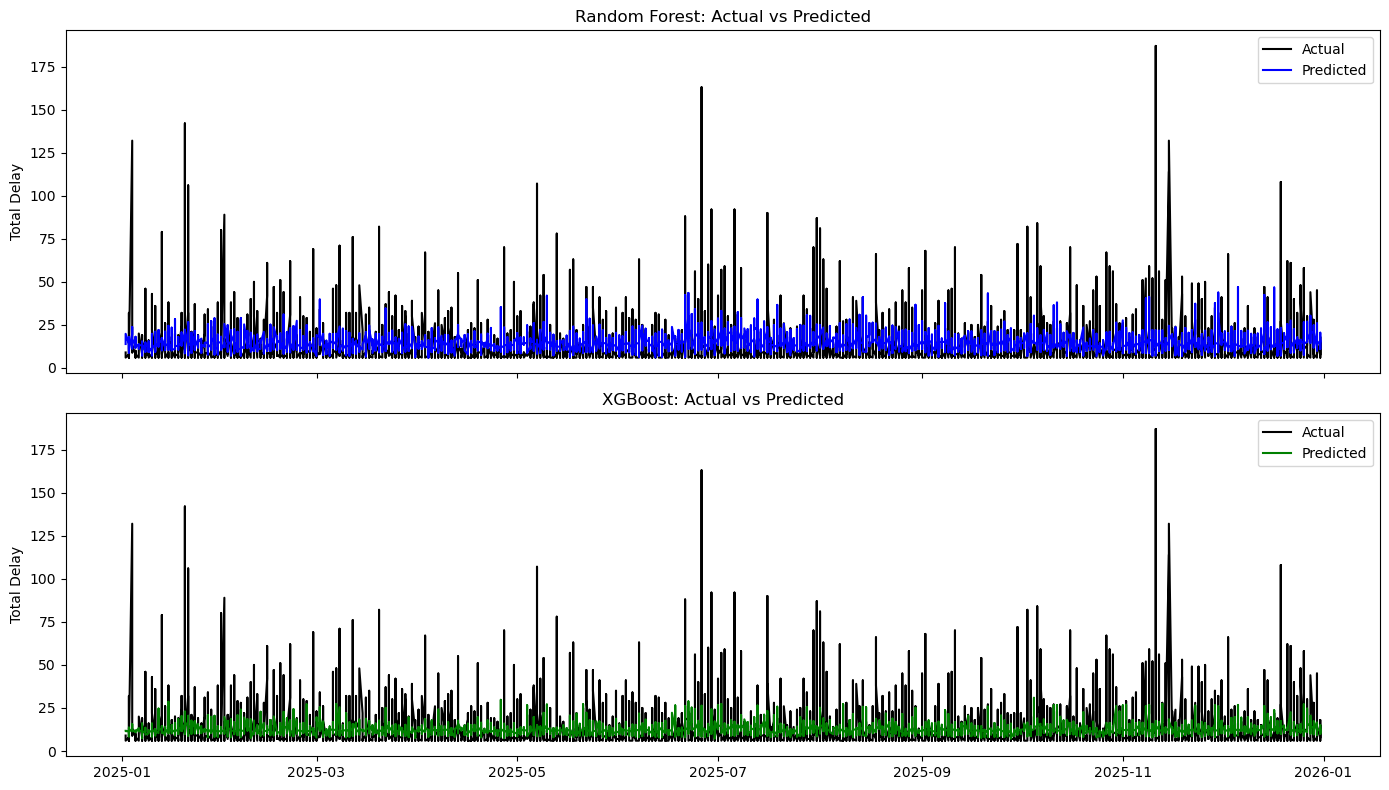

In [153]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Convert predictions to pandas Series for easy slicing
pred_rf_series = pd.Series(predictions_rf).reset_index(drop=True)
pred_xgb_series = pd.Series(predictions_xgb).reset_index(drop=True)
y_test_series = y_test.reset_index(drop=True)

# Slice the last 11,000 entries (Approx 2025)
dates_last = dates_test.tail(11000)
y_test_last = y_test_series.tail(11000)
pred_rf_last = pred_rf_series.tail(11000)
pred_xgb_last = pred_xgb_series.tail(11000)

# Random Forest
axes[0].plot(dates_last, y_test_last, label="Actual", color="black")
axes[0].plot(dates_last, pred_rf_last, label="Predicted", color="blue")
axes[0].set_title("Random Forest: Actual vs Predicted")
axes[0].set_ylabel("Total Delay")
axes[0].legend()

# XGBoost
axes[1].plot(dates_last, y_test_last, label="Actual", color="black")
axes[1].plot(dates_last, pred_xgb_last, label="Predicted", color="green")
axes[1].set_title("XGBoost: Actual vs Predicted")
axes[1].set_ylabel("Total Delay")
axes[1].legend()

plt.tight_layout()
plt.show()

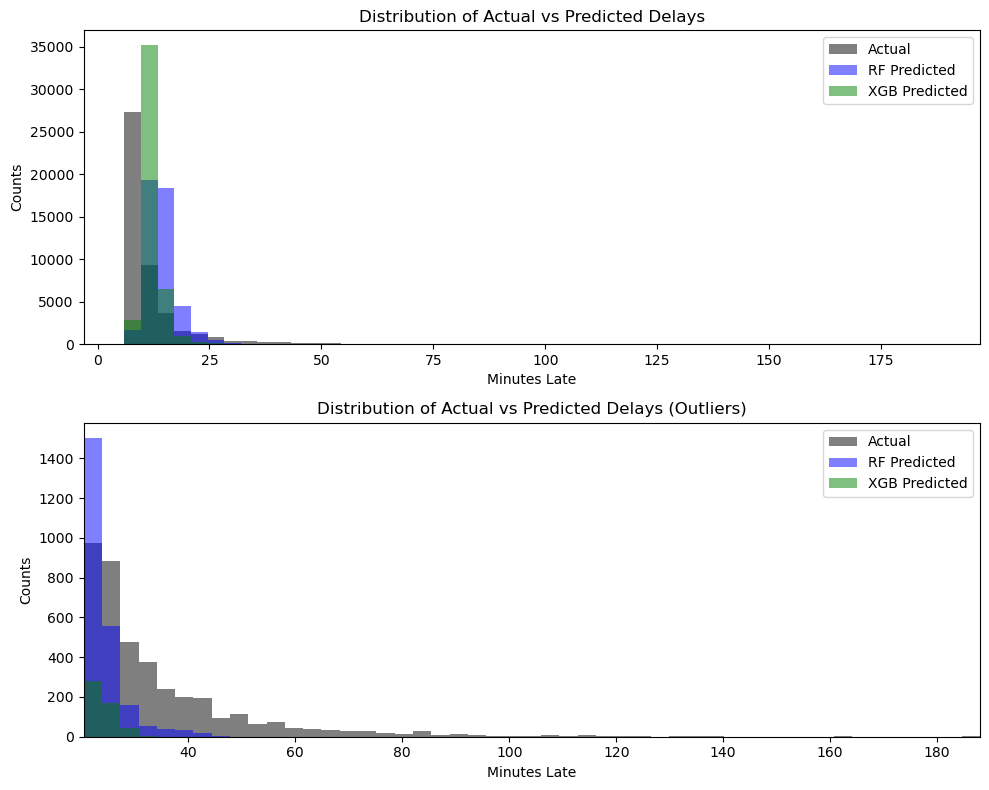

In [154]:
# Standardized bins
combined = np.concatenate([y_test, predictions_rf, predictions_xgb])
xmin, xmax = combined.min(), combined.max()
bins = np.linspace(xmin, xmax, 50)

# Outlier range
lower, upper = np.percentile(combined, [95, 100])
outlier_bins = np.linspace(lower, upper, 50)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].hist(y_test, bins=bins, alpha=0.5, label="Actual", color="black")
axes[0].hist(predictions_rf, bins=bins, alpha=0.5, label="RF Predicted", color="blue")
axes[0].hist(predictions_xgb, bins=bins, alpha=0.5, label="XGB Predicted", color="green")
axes[0].set_xlabel("Minutes Late")
axes[0].set_ylabel("Counts")
axes[0].set_title("Distribution of Actual vs Predicted Delays")
axes[0].legend()

axes[1].hist(y_test, bins=outlier_bins, alpha=0.5, label="Actual", color="black")
axes[1].hist(predictions_rf, bins=outlier_bins, alpha=0.5, label="RF Predicted", color="blue")
axes[1].hist(predictions_xgb, bins=outlier_bins, alpha=0.5, label="XGB Predicted", color="green")
axes[1].set_xlim(lower, upper)
axes[1].set_xlabel("Minutes Late")
axes[1].set_ylabel("Counts")
axes[1].set_title("Distribution of Actual vs Predicted Delays (Outliers)")
axes[1].legend()

plt.tight_layout()
plt.show()

## XGB and RF Analysis/Visuals

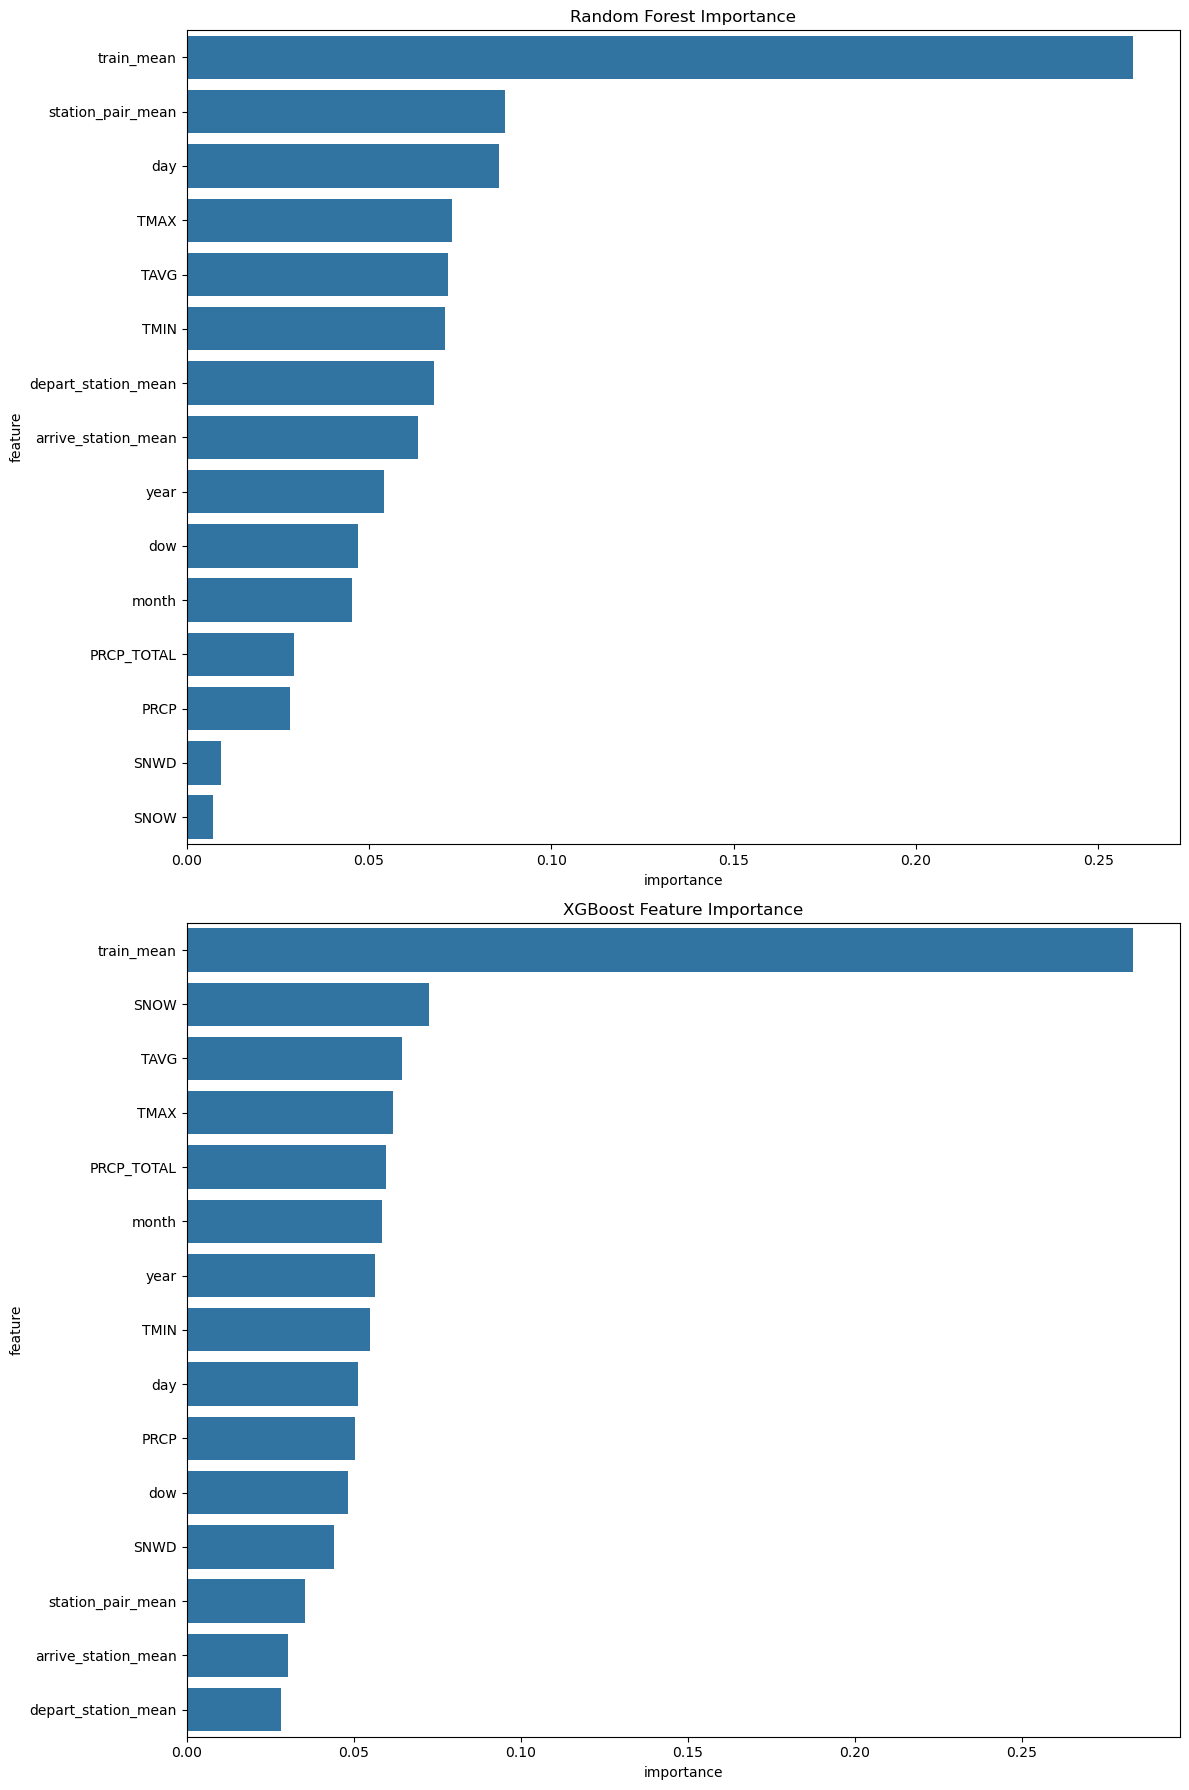

In [155]:
#TODO
# Graphs and stuff, probably some training losses and precision/recall goodies

rf_importance = rf_model.feature_importances_
rf_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_importance
}).sort_values(by="importance", ascending=False)

xgb_importance = xgb_model.feature_importances_
xgb_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_importance
}).sort_values(by="importance", ascending=False)


# Plots
fig, axes = plt.subplots(2, 1, figsize=(12, 18))

sns.barplot(x="importance", y="feature", data=rf_df, ax=axes[0])
axes[0].set_title("Random Forest Importance")

sns.barplot(x="importance", y="feature", data=xgb_df, ax=axes[1])
axes[1].set_title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

# Drop Extreme Ouliers for Day to Day Operations

In [156]:
# Three sigma rule for outliers
mean = df_training['minutes_late'].mean()
std = df_training['minutes_late'].std()

# Define 3-sigma bounds
lower_bound = mean - 3*std
upper_bound = mean + 3*std

# Since delays can't be negative, clip the lower bound at 0
lower_bound = max(lower_bound, 0)

# Filter dataset to keep only values within 3 sigma
df_clean = df_training[(df_training['minutes_late'] >= lower_bound) &
                       (df_training['minutes_late'] <= upper_bound)]

dropped = (len(df_training) - len(df_clean))
print(f"Outliers Dropped: {dropped}")

y = df_clean["minutes_late"]
X = df_clean.drop(columns=["minutes_late"])

Outliers Dropped: 4559


In [157]:
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test  = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test  = y.iloc[split_idx:].copy()

# Save test dates for plotting
dates_test = X_test["DATE"].reset_index(drop=True)

# Drop DATE before training
X_train.drop(columns=["DATE"], inplace=True)
X_test.drop(columns=["DATE"], inplace=True)

cat_cols = ["train", "depart_station", "arrive_station", "station_pair"]

for col in cat_cols:
    means = y_train.groupby(X_train[col]).mean()

    X_train[col + "_mean"] = X_train[col].map(means)
    X_test[col + "_mean"]  = X_test[col].map(means)

# Drop original categorical columns
X_train.drop(columns=cat_cols, inplace=True)
X_test.drop(columns=cat_cols, inplace=True)

# Fill unseen categories with global mean
global_mean = y_train.mean()
X_train.fillna(global_mean, inplace=True)
X_test.fillna(global_mean, inplace=True)

y_train = y_train.clip(upper=y_train.quantile(0.99))

# Reset indices to ensure perfect alignment
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)

print(X_train.head())

   PRCP  SNOW  ...  arrive_station_mean  station_pair_mean
0  0.24   5.2  ...            10.657616          10.524735
1  0.24   5.2  ...            11.541014          11.446424
2  0.24   5.2  ...            10.657616           9.444203
3  0.24   5.2  ...            11.541014          11.446424
4  0.24   5.2  ...            10.657616          10.373418

[5 rows x 15 columns]


C:\Users\skylerturner\AppData\Local\Temp\ipykernel_6356\2534555264.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = y_train.groupby(X_train[col]).mean()
C:\Users\skylerturner\AppData\Local\Temp\ipykernel_6356\2534555264.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = y_train.groupby(X_train[col]).mean()


In [158]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions and evaluate
predictions_rf = rf_model.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions_rf):.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, predictions_rf)):.2f} minutes")
print(f"R-squared Score: {r2_score(y_test, predictions_rf):.2f}")
mape = mean_absolute_percentage_error(y_test, predictions_rf) * 100
print(f"MAPE: {mape:.2f}%")

Mean Absolute Error: 5.12 minutes
Root Mean Squared Error (RMSE): 6.63 minutes
R-squared Score: -0.14
MAPE: 54.68%


In [159]:
# XGB Code
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

xgb_model.fit(X_train, y_train)

predictions_xgb = xgb_model.predict(X_test)

print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions_xgb):.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, predictions_xgb)):.2f} minutes")
print(f"R-squared Score: {r2_score(y_test, predictions_xgb):.2f}")
mape = mean_absolute_percentage_error(y_test, predictions_xgb) * 100
print(f"MAPE: {mape:.2f}%")

Mean Absolute Error: 4.52 minutes
Root Mean Squared Error (RMSE): 6.28 minutes
R-squared Score: -0.02
MAPE: 45.30%


In [160]:
# Convert predictions and y_test to Series
y_test_series = pd.Series(y_test)
pred_rf_series = pd.Series(predictions_rf)
pred_xgb_series = pd.Series(predictions_xgb)

# Compute averages
actual_avg = y_test_series.mean()
rf_avg = pred_rf_series.mean()
xgb_avg = pred_xgb_series.mean()

print(f"Average Actual Delay: {actual_avg:.2f} minutes")
print(f"Average RF Predicted Delay: {rf_avg:.2f} minutes")
print(f"Average XGB Predicted Delay: {xgb_avg:.2f} minutes")

Average Actual Delay: 10.73 minutes
Average RF Predicted Delay: 12.58 minutes
Average XGB Predicted Delay: 11.44 minutes


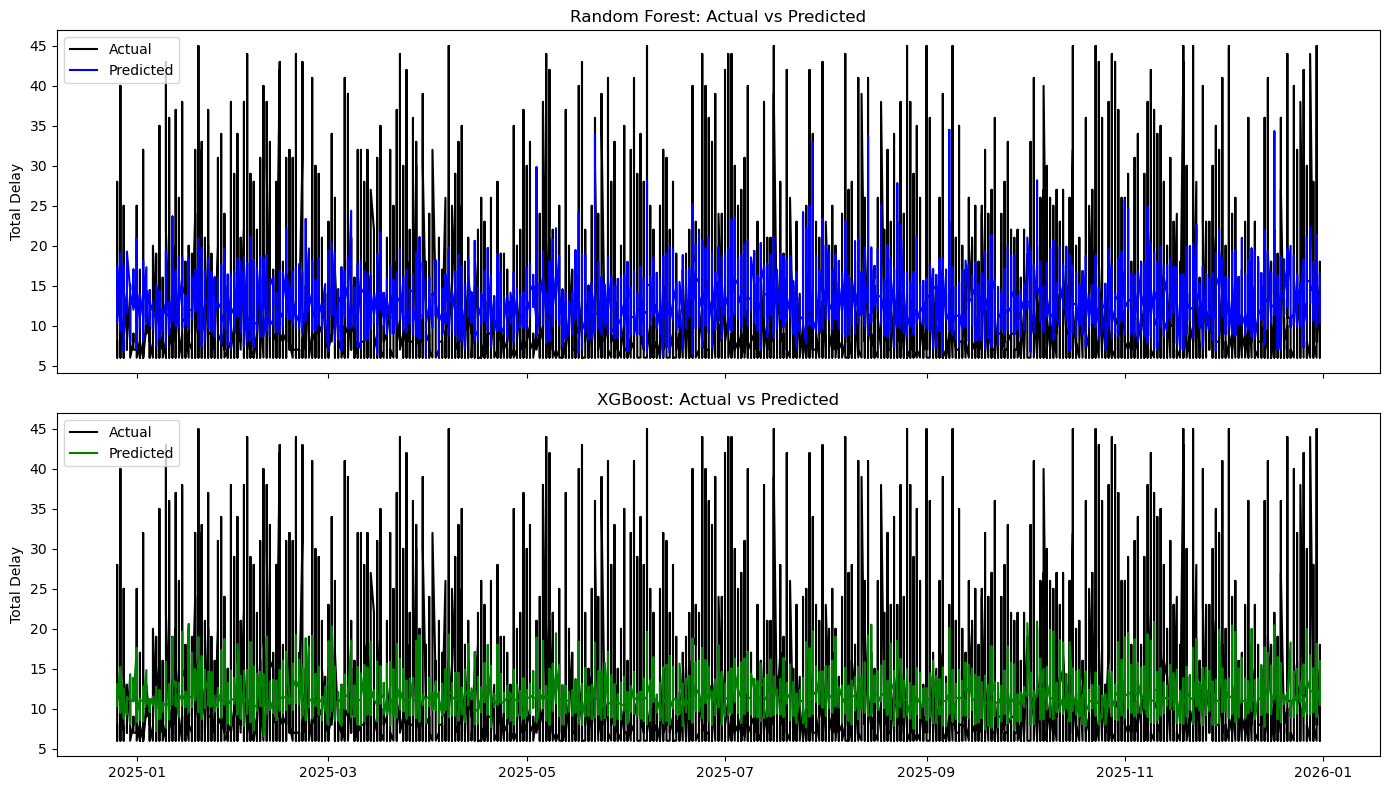

In [161]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Convert predictions to pandas Series for easy slicing
pred_rf_series = pd.Series(predictions_rf).reset_index(drop=True)
pred_xgb_series = pd.Series(predictions_xgb).reset_index(drop=True)
y_test_series = y_test.reset_index(drop=True)

# Slice the last 11,000 entries (Approx 2025)
dates_last = dates_test.tail(11000)
y_test_last = y_test_series.tail(11000)
pred_rf_last = pred_rf_series.tail(11000)
pred_xgb_last = pred_xgb_series.tail(11000)

# Random Forest
axes[0].plot(dates_last, y_test_last, label="Actual", color="black")
axes[0].plot(dates_last, pred_rf_last, label="Predicted", color="blue")
axes[0].set_title("Random Forest: Actual vs Predicted")
axes[0].set_ylabel("Total Delay")
axes[0].legend()

# XGBoost
axes[1].plot(dates_last, y_test_last, label="Actual", color="black")
axes[1].plot(dates_last, pred_xgb_last, label="Predicted", color="green")
axes[1].set_title("XGBoost: Actual vs Predicted")
axes[1].set_ylabel("Total Delay")
axes[1].legend()

plt.tight_layout()
plt.show()

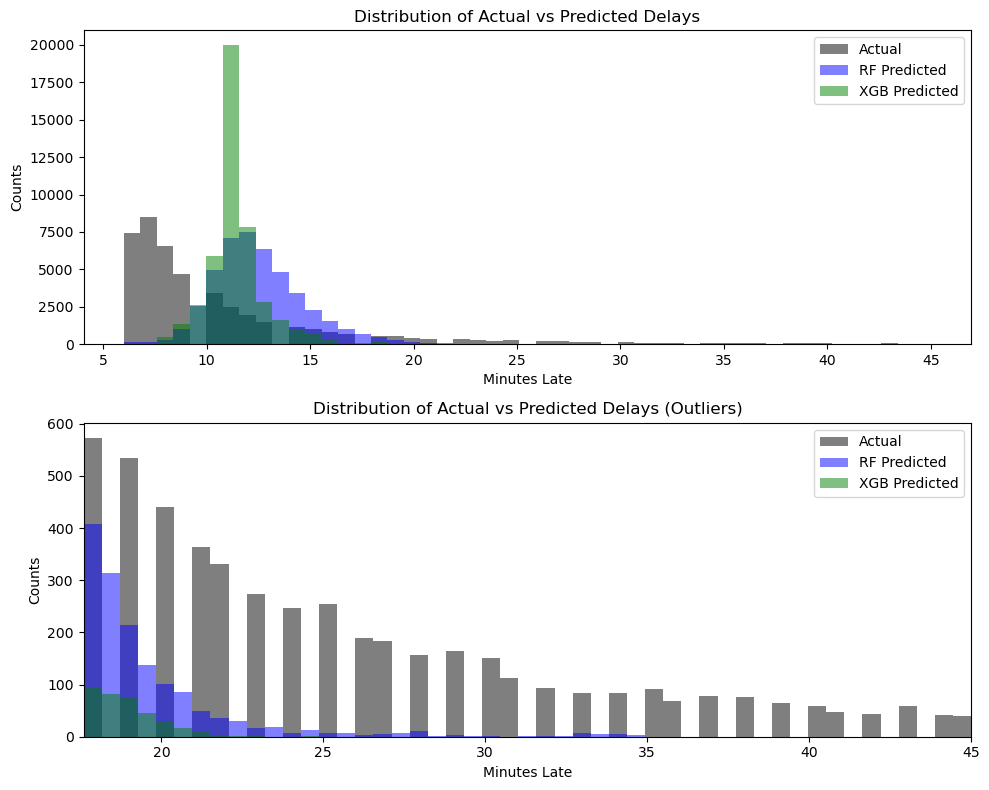

In [162]:
# Standardized bins
combined = np.concatenate([y_test, predictions_rf, predictions_xgb])
xmin, xmax = combined.min(), combined.max()
bins = np.linspace(xmin, xmax, 50)

# Outlier range
lower, upper = np.percentile(combined, [95, 100])
outlier_bins = np.linspace(lower, upper, 50)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].hist(y_test, bins=bins, alpha=0.5, label="Actual", color="black")
axes[0].hist(predictions_rf, bins=bins, alpha=0.5, label="RF Predicted", color="blue")
axes[0].hist(predictions_xgb, bins=bins, alpha=0.5, label="XGB Predicted", color="green")
axes[0].set_xlabel("Minutes Late")
axes[0].set_ylabel("Counts")
axes[0].set_title("Distribution of Actual vs Predicted Delays")
axes[0].legend()

axes[1].hist(y_test, bins=outlier_bins, alpha=0.5, label="Actual", color="black")
axes[1].hist(predictions_rf, bins=outlier_bins, alpha=0.5, label="RF Predicted", color="blue")
axes[1].hist(predictions_xgb, bins=outlier_bins, alpha=0.5, label="XGB Predicted", color="green")
axes[1].set_xlim(lower, upper)
axes[1].set_xlabel("Minutes Late")
axes[1].set_ylabel("Counts")
axes[1].set_title("Distribution of Actual vs Predicted Delays (Outliers)")
axes[1].legend()

plt.tight_layout()
plt.show()

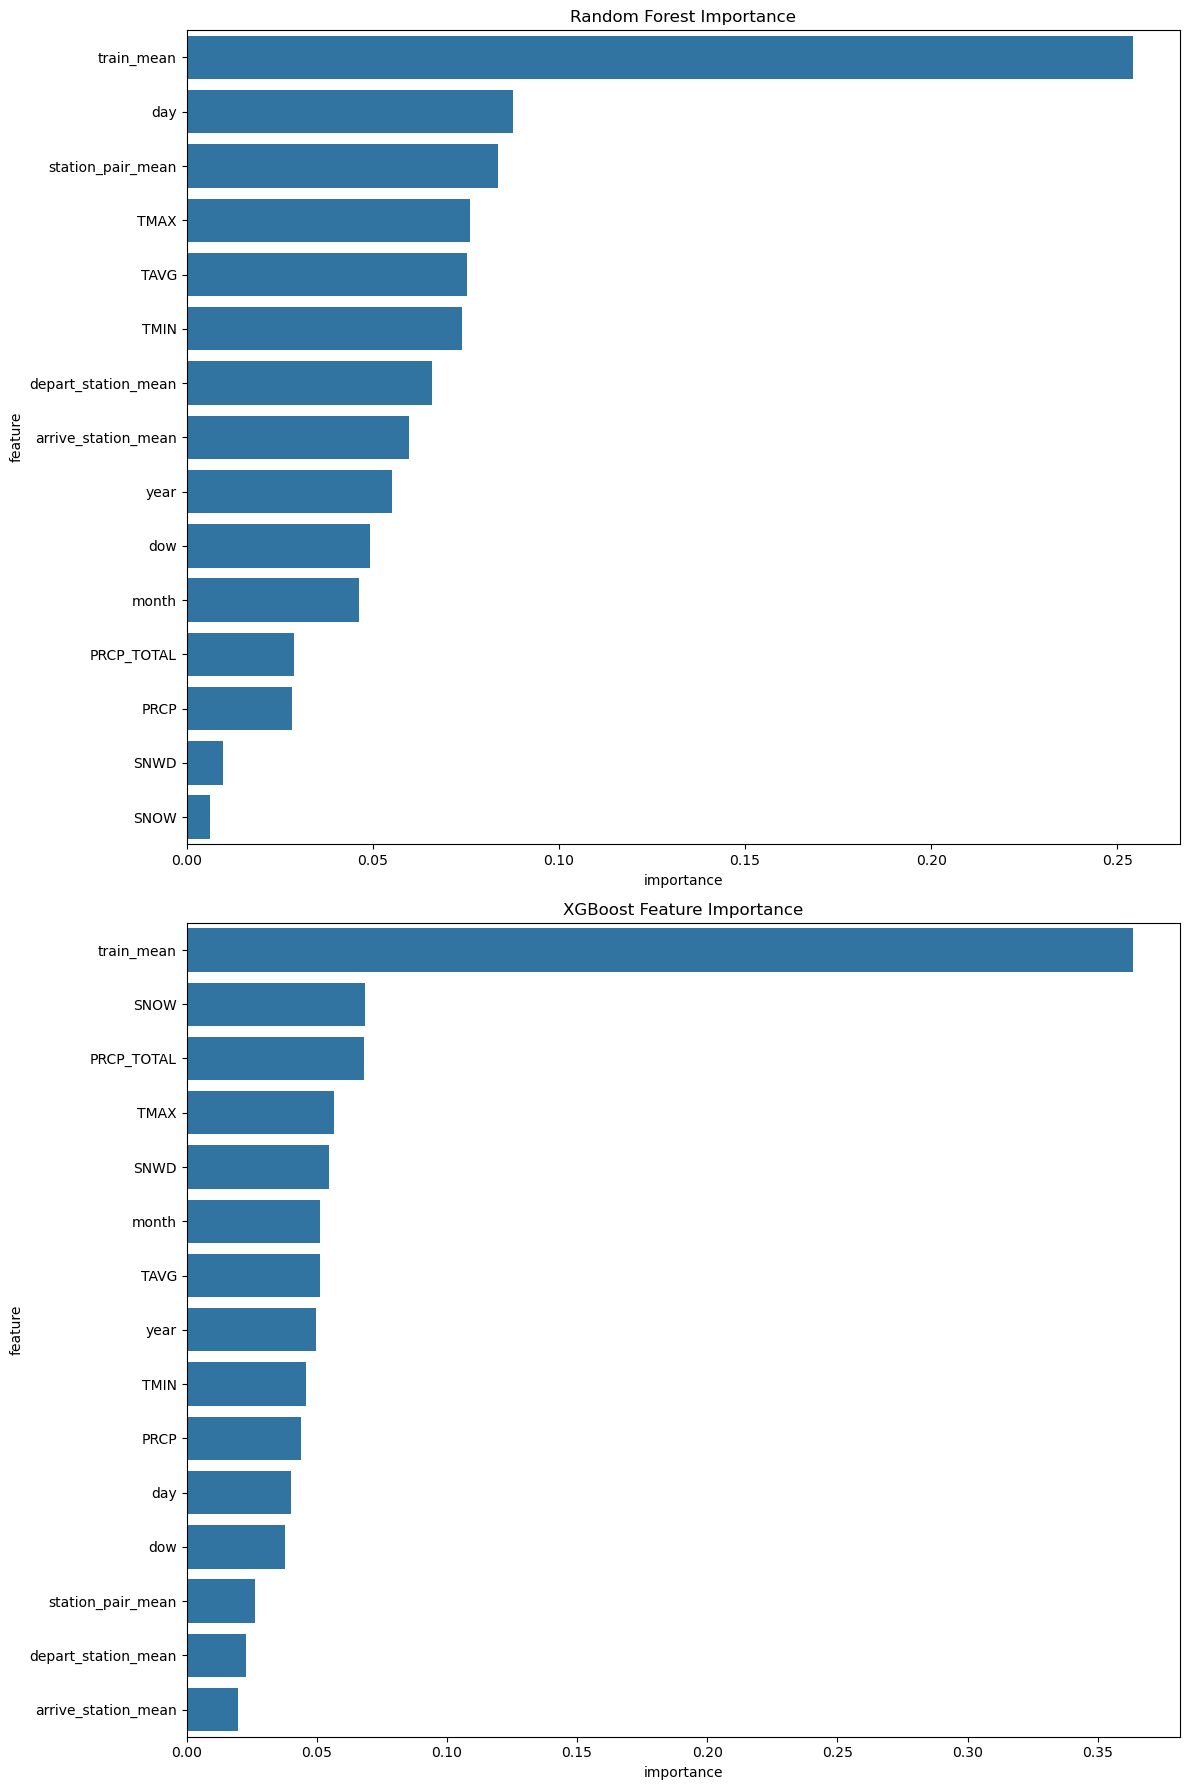

In [163]:
#TODO
# Graphs and stuff, probably some training losses and precision/recall goodies
rf_importance = rf_model.feature_importances_
rf_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_importance
}).sort_values(by="importance", ascending=False)

xgb_importance = xgb_model.feature_importances_
xgb_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_importance
}).sort_values(by="importance", ascending=False)


# Plots
fig, axes = plt.subplots(2, 1, figsize=(12, 18))

sns.barplot(x="importance", y="feature", data=rf_df, ax=axes[0])
axes[0].set_title("Random Forest Importance")

sns.barplot(x="importance", y="feature", data=xgb_df, ax=axes[1])
axes[1].set_title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

## Too Much Overfitting

In [164]:
X_train.drop(columns='train_mean', inplace=True)
X_test.drop(columns='train_mean', inplace=True)

In [165]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions and evaluate
predictions_rf = rf_model.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions_rf):.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, predictions_rf)):.2f} minutes")
print(f"R-squared Score: {r2_score(y_test, predictions_rf):.2f}")
mape = mean_absolute_percentage_error(y_test, predictions_rf) * 100
print(f"MAPE: {mape:.2f}%")

# XGB Code
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

xgb_model.fit(X_train, y_train)

predictions_xgb = xgb_model.predict(X_test)

print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions_xgb):.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, predictions_xgb)):.2f} minutes")
print(f"R-squared Score: {r2_score(y_test, predictions_xgb):.2f}")
mape = mean_absolute_percentage_error(y_test, predictions_xgb) * 100
print(f"MAPE: {mape:.2f}%")

# Convert predictions and y_test to Series
y_test_series = pd.Series(y_test)
pred_rf_series = pd.Series(predictions_rf)
pred_xgb_series = pd.Series(predictions_xgb)

# Compute averages
actual_avg = y_test_series.mean()
rf_avg = pred_rf_series.mean()
xgb_avg = pred_xgb_series.mean()

print(f"Average Actual Delay: {actual_avg:.2f} minutes")
print(f"Average RF Predicted Delay: {rf_avg:.2f} minutes")
print(f"Average XGB Predicted Delay: {xgb_avg:.2f} minutes")

Mean Absolute Error: 4.88 minutes
Root Mean Squared Error (RMSE): 6.44 minutes
R-squared Score: -0.08
MAPE: 51.05%
Mean Absolute Error: 4.41 minutes
Root Mean Squared Error (RMSE): 6.14 minutes
R-squared Score: 0.02
MAPE: 43.94%
Average Actual Delay: 10.73 minutes
Average RF Predicted Delay: 12.24 minutes
Average XGB Predicted Delay: 11.41 minutes


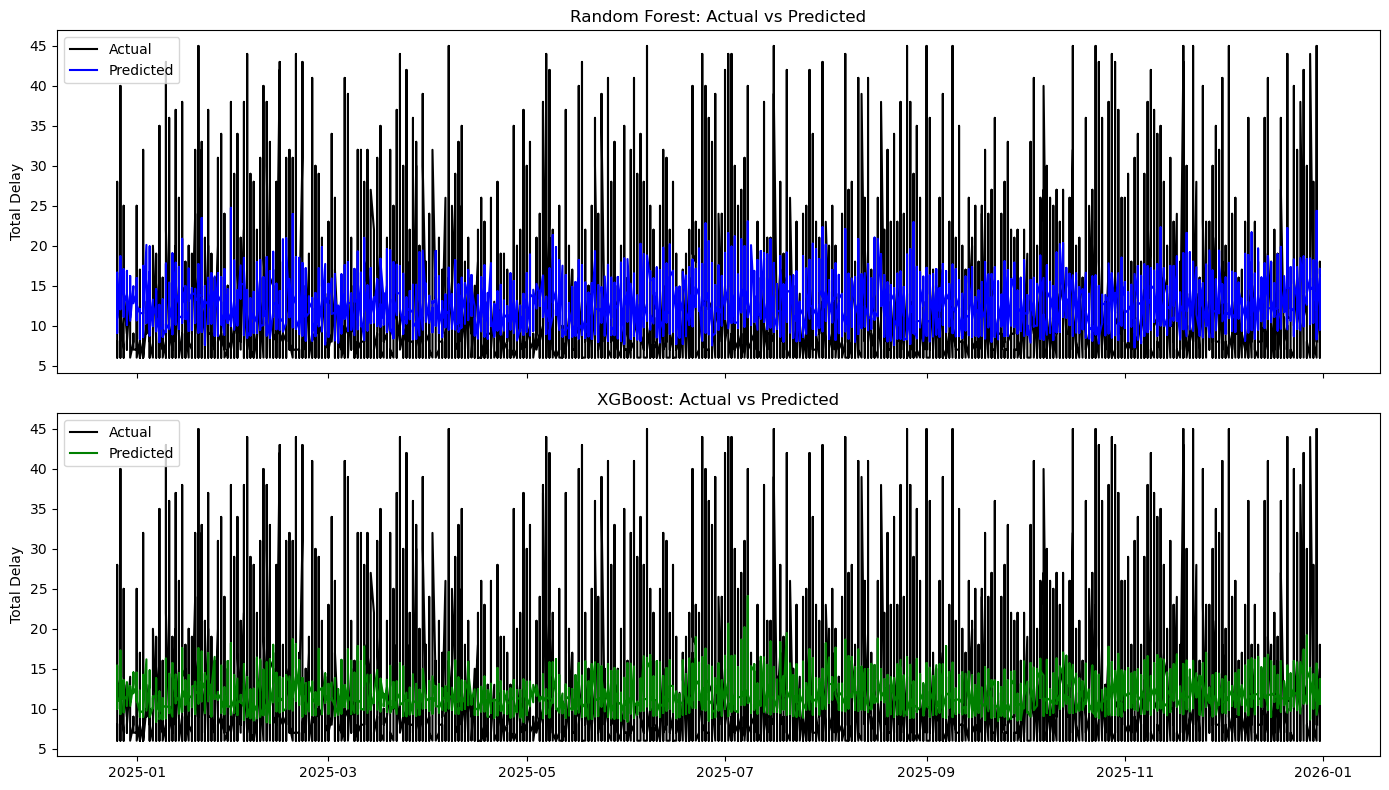

In [166]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Convert predictions to pandas Series for easy slicing
pred_rf_series = pd.Series(predictions_rf).reset_index(drop=True)
pred_xgb_series = pd.Series(predictions_xgb).reset_index(drop=True)
y_test_series = y_test.reset_index(drop=True)

# Slice the last 11,000 entries (Approx 2025)
dates_last = dates_test.tail(11000)
y_test_last = y_test_series.tail(11000)
pred_rf_last = pred_rf_series.tail(11000)
pred_xgb_last = pred_xgb_series.tail(11000)

# Random Forest
axes[0].plot(dates_last, y_test_last, label="Actual", color="black")
axes[0].plot(dates_last, pred_rf_last, label="Predicted", color="blue")
axes[0].set_title("Random Forest: Actual vs Predicted")
axes[0].set_ylabel("Total Delay")
axes[0].legend()

# XGBoost
axes[1].plot(dates_last, y_test_last, label="Actual", color="black")
axes[1].plot(dates_last, pred_xgb_last, label="Predicted", color="green")
axes[1].set_title("XGBoost: Actual vs Predicted")
axes[1].set_ylabel("Total Delay")
axes[1].legend()

plt.tight_layout()
plt.show()

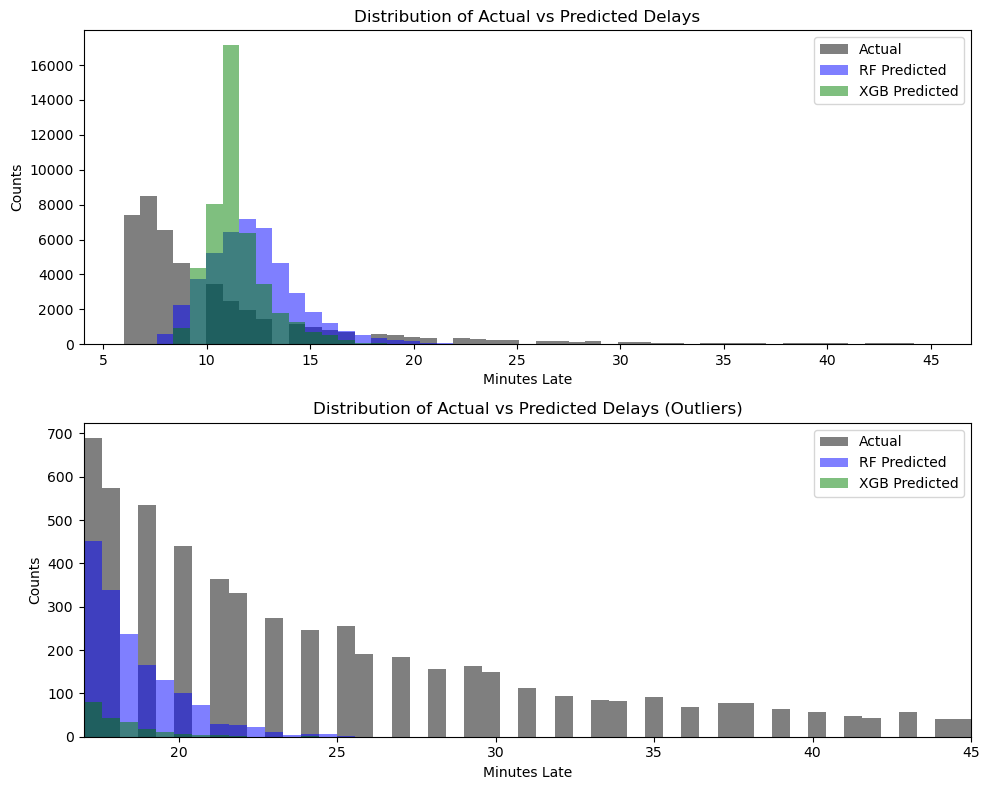

In [167]:
# Standardized bins
combined = np.concatenate([y_test, predictions_rf, predictions_xgb])
xmin, xmax = combined.min(), combined.max()
bins = np.linspace(xmin, xmax, 50)

# Outlier range
lower, upper = np.percentile(combined, [95, 100])
outlier_bins = np.linspace(lower, upper, 50)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].hist(y_test, bins=bins, alpha=0.5, label="Actual", color="black")
axes[0].hist(predictions_rf, bins=bins, alpha=0.5, label="RF Predicted", color="blue")
axes[0].hist(predictions_xgb, bins=bins, alpha=0.5, label="XGB Predicted", color="green")
axes[0].set_xlabel("Minutes Late")
axes[0].set_ylabel("Counts")
axes[0].set_title("Distribution of Actual vs Predicted Delays")
axes[0].legend()

axes[1].hist(y_test, bins=outlier_bins, alpha=0.5, label="Actual", color="black")
axes[1].hist(predictions_rf, bins=outlier_bins, alpha=0.5, label="RF Predicted", color="blue")
axes[1].hist(predictions_xgb, bins=outlier_bins, alpha=0.5, label="XGB Predicted", color="green")
axes[1].set_xlim(lower, upper)
axes[1].set_xlabel("Minutes Late")
axes[1].set_ylabel("Counts")
axes[1].set_title("Distribution of Actual vs Predicted Delays (Outliers)")
axes[1].legend()

plt.tight_layout()
plt.show()

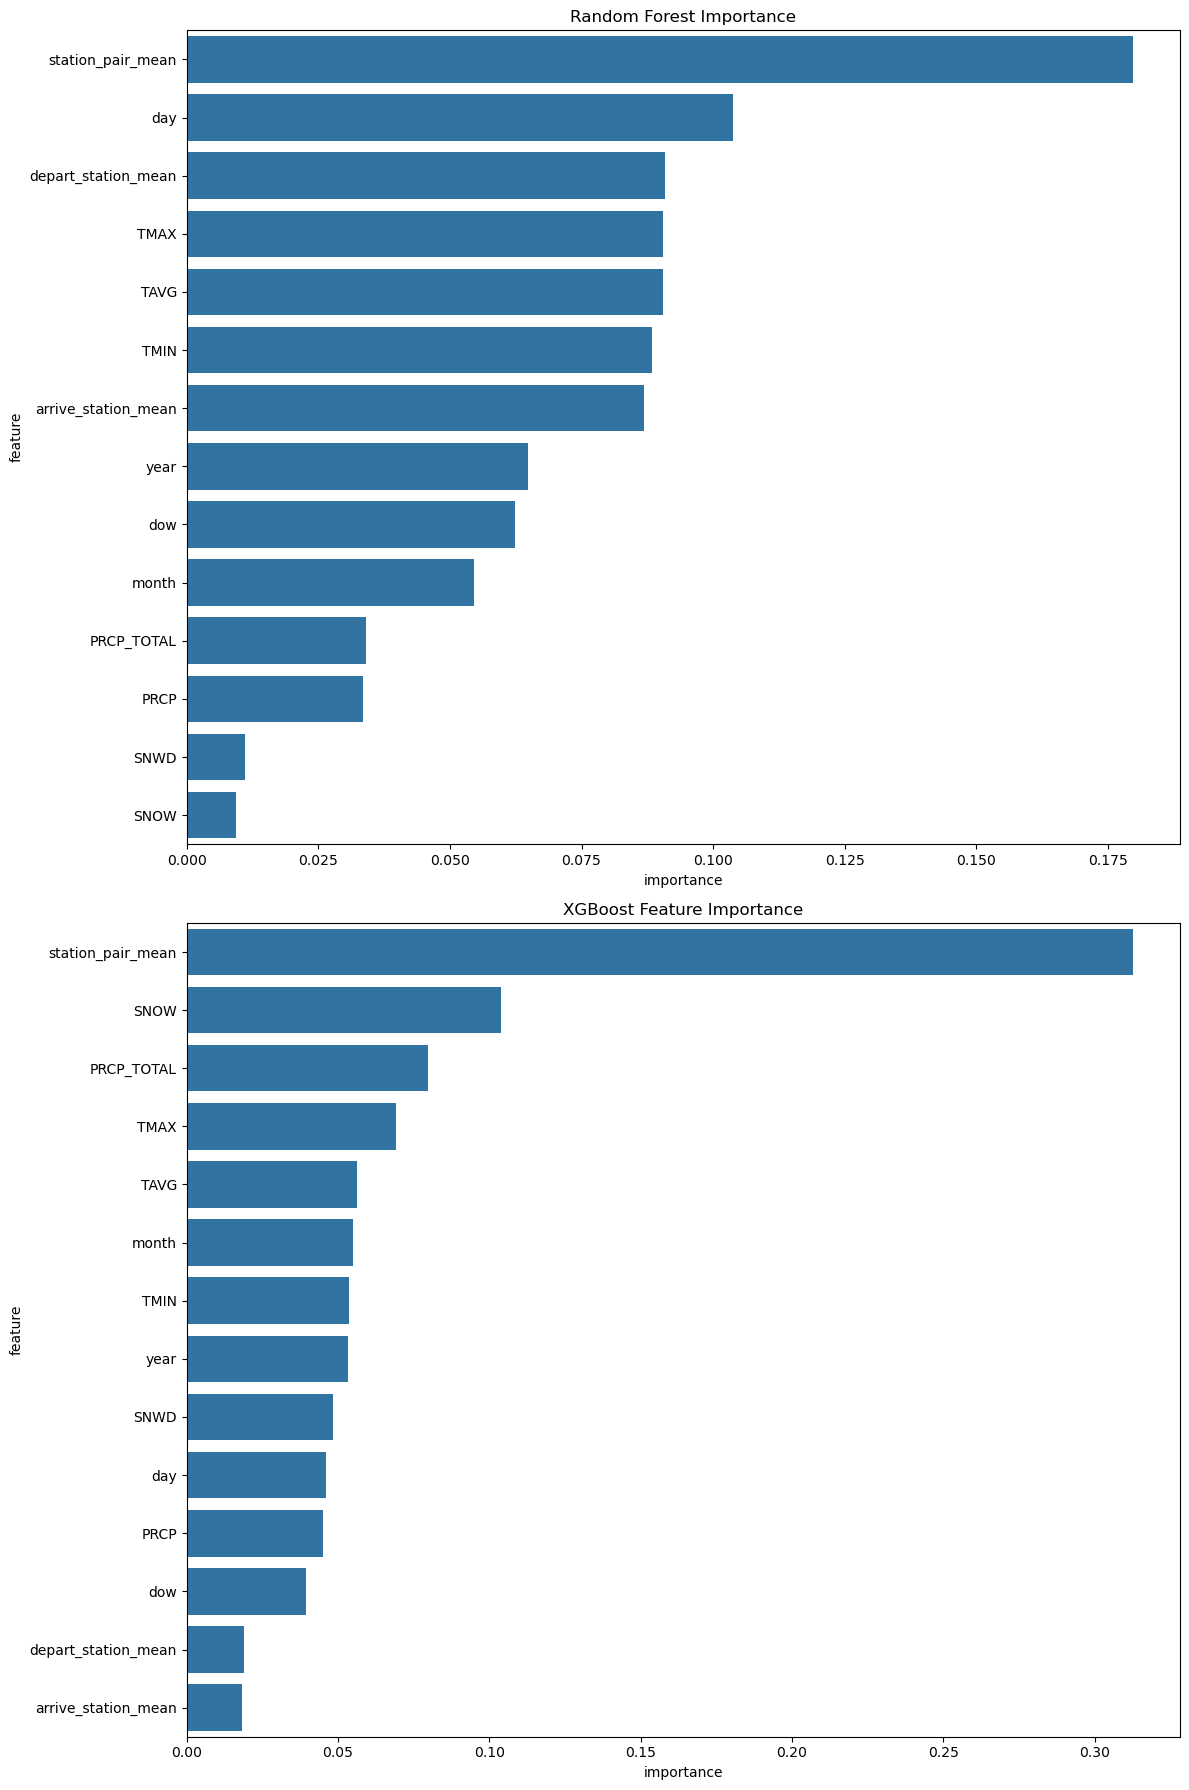

In [168]:
#TODO
# Graphs and stuff, probably some training losses and precision/recall goodies
rf_importance = rf_model.feature_importances_
rf_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_importance
}).sort_values(by="importance", ascending=False)

xgb_importance = xgb_model.feature_importances_
xgb_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_importance
}).sort_values(by="importance", ascending=False)


# Plots
fig, axes = plt.subplots(2, 1, figsize=(12, 18))

sns.barplot(x="importance", y="feature", data=rf_df, ax=axes[0])
axes[0].set_title("Random Forest Importance")

sns.barplot(x="importance", y="feature", data=xgb_df, ax=axes[1])
axes[1].set_title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

## Data Might be Overfitting to Earlier Years

In [169]:
df_small = df.copy()

# Filter for rows on or after 2022-01-01
df_small = df_small[df_small["DATE"] >= "2022-01-01"]

# Sort chronologically
df_small = df_small.sort_values("DATE")

# Drop rows with missing target
df_small = df_small.dropna(subset=["minutes_late"])

# Reset index for safety
df_small = df_small.reset_index(drop=True)

# Station pair feature
df_small["station_pair"] = (
    df_small["depart_station"].astype(str)
    + "→"
    + df_small["arrive_station"].astype(str)
)

# Time-based features
df_small["year"]  = df_small["DATE"].dt.year
df_small["month"] = df_small["DATE"].dt.month
df_small["day"]   = df_small["DATE"].dt.day
df_small["dow"]   = df_small["DATE"].dt.dayofweek

# Three sigma rule for outliers
mean = df_small['minutes_late'].mean()
std = df_small['minutes_late'].std()

# Define 3-sigma bounds
upper_bound = mean + 3*std

# Filter dataset to keep only values within 3 sigma
df_small_clean = df_small[df_small['minutes_late'] <= upper_bound]

dropped = (len(df_small) - len(df_small_clean))
print(f"Outliers Dropped: {dropped}")

y = df_small_clean["minutes_late"]
X = df_small_clean.drop(columns=["minutes_late"])

Outliers Dropped: 1009


In [170]:
# Ensure DATE is datetime
X["DATE"] = pd.to_datetime(X["DATE"])

# Split by year
X_train = X[X["DATE"].dt.year < 2025].copy()
X_test  = X[X["DATE"].dt.year == 2025].copy()

y_train = y.loc[X_train.index].copy()
y_test  = y.loc[X_test.index].copy()

# Save test dates for plotting
dates_test = X_test["DATE"].reset_index(drop=True)

# Drop DATE and any helper columns before training
X_train.drop(columns=["DATE", "train"], inplace=True)
X_test.drop(columns=["DATE", "train"], inplace=True)

# Categorical encoding
cat_cols = ["depart_station", "arrive_station", "station_pair"]

for col in cat_cols:
    means = y_train.groupby(X_train[col]).mean()
    X_train[col + "_mean"] = X_train[col].map(means)
    X_test[col + "_mean"]  = X_test[col].map(means)

# Drop original categorical columns
X_train.drop(columns=cat_cols, inplace=True)
X_test.drop(columns=cat_cols, inplace=True)

# Fill unseen categories with global mean
global_mean = y_train.mean()
X_train.fillna(global_mean, inplace=True)
X_test.fillna(global_mean, inplace=True)

# Reset indices
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(X_train.head())

   PRCP  SNOW  ...  arrive_station_mean  station_pair_mean
0  0.06   0.0  ...             9.560258          10.240958
1  0.06   0.0  ...            13.811966          14.145833
2  0.06   0.0  ...            13.811966          14.145833
3  0.06   0.0  ...            12.666855          13.556452
4  0.06   0.0  ...             9.560258           9.844947

[5 rows x 14 columns]


C:\Users\skylerturner\AppData\Local\Temp\ipykernel_6356\2286496520.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = y_train.groupby(X_train[col]).mean()
C:\Users\skylerturner\AppData\Local\Temp\ipykernel_6356\2286496520.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = y_train.groupby(X_train[col]).mean()


In [171]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions and evaluate
predictions_rf = rf_model.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions_rf):.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, predictions_rf)):.2f} minutes")
print(f"R-squared Score: {r2_score(y_test, predictions_rf):.2f}")
mape = mean_absolute_percentage_error(y_test, predictions_rf) * 100
print(f"MAPE: {mape:.2f}%")

# XGB Code
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

xgb_model.fit(X_train, y_train)

predictions_xgb = xgb_model.predict(X_test)

print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions_xgb):.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, predictions_xgb)):.2f} minutes")
print(f"R-squared Score: {r2_score(y_test, predictions_xgb):.2f}")
mape = mean_absolute_percentage_error(y_test, predictions_xgb) * 100
print(f"MAPE: {mape:.2f}%")

# Convert predictions and y_test to Series
y_test_series = pd.Series(y_test)
pred_rf_series = pd.Series(predictions_rf)
pred_xgb_series = pd.Series(predictions_xgb)

# Compute averages
actual_avg = y_test_series.mean()
rf_avg = pred_rf_series.mean()
xgb_avg = pred_xgb_series.mean()

print(f"Average Actual Delay: {actual_avg:.2f} minutes")
print(f"Average RF Predicted Delay: {rf_avg:.2f} minutes")
print(f"Average XGB Predicted Delay: {xgb_avg:.2f} minutes")

Mean Absolute Error: 4.20 minutes
Root Mean Squared Error (RMSE): 5.80 minutes
R-squared Score: -0.03
MAPE: 42.31%
Mean Absolute Error: 3.99 minutes
Root Mean Squared Error (RMSE): 5.66 minutes
R-squared Score: 0.02
MAPE: 39.02%
Average Actual Delay: 10.46 minutes
Average RF Predicted Delay: 11.02 minutes
Average XGB Predicted Delay: 10.65 minutes


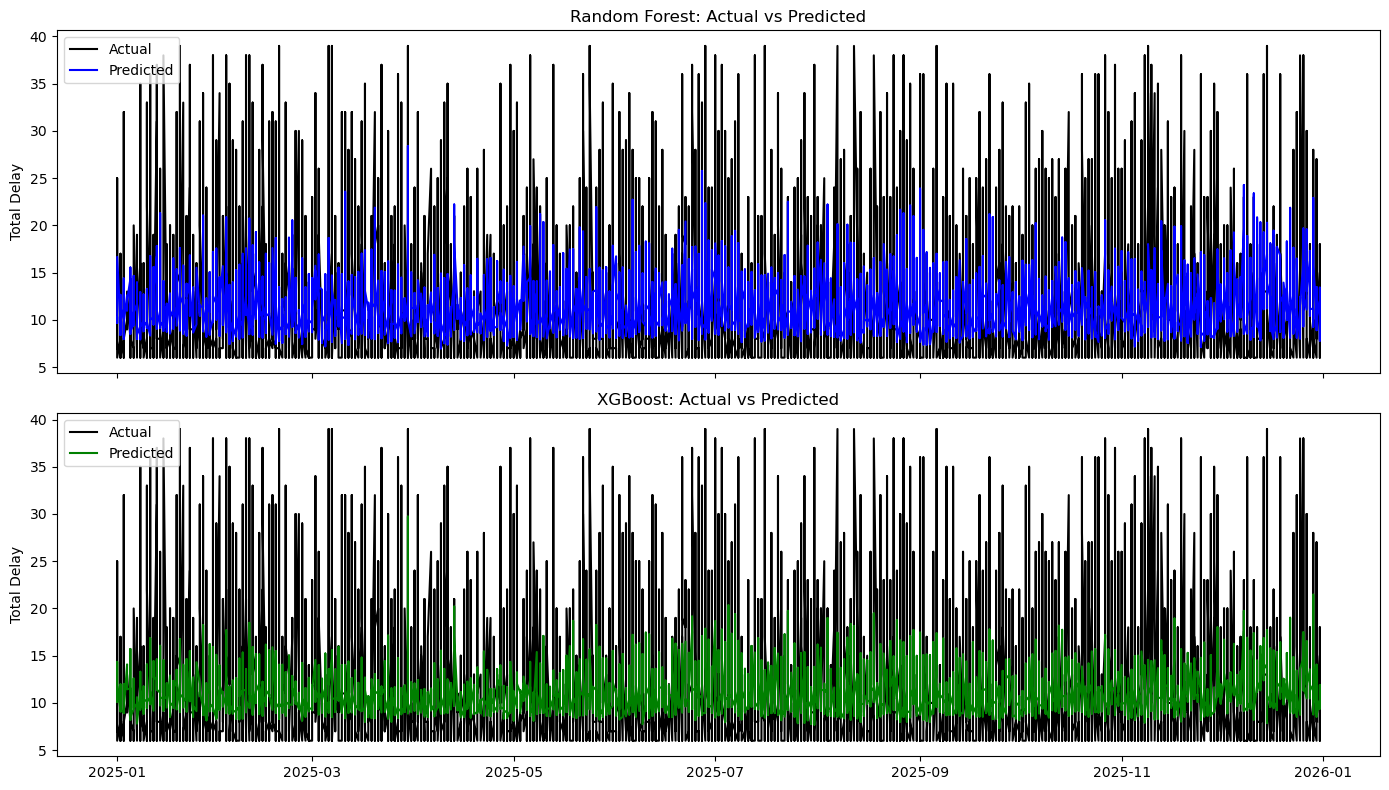

In [172]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Convert predictions to pandas Series for easy slicing
pred_rf_series = pd.Series(predictions_rf).reset_index(drop=True)
pred_xgb_series = pd.Series(predictions_xgb).reset_index(drop=True)
y_test_series = y_test.reset_index(drop=True)

# Slice the last 11,000 entries (Approx 2025)
dates_last = dates_test.tail(11000)
y_test_last = y_test_series.tail(11000)
pred_rf_last = pred_rf_series.tail(11000)
pred_xgb_last = pred_xgb_series.tail(11000)

# Random Forest
axes[0].plot(dates_last, y_test_last, label="Actual", color="black")
axes[0].plot(dates_last, pred_rf_last, label="Predicted", color="blue")
axes[0].set_title("Random Forest: Actual vs Predicted")
axes[0].set_ylabel("Total Delay")
axes[0].legend()

# XGBoost
axes[1].plot(dates_last, y_test_last, label="Actual", color="black")
axes[1].plot(dates_last, pred_xgb_last, label="Predicted", color="green")
axes[1].set_title("XGBoost: Actual vs Predicted")
axes[1].set_ylabel("Total Delay")
axes[1].legend()

plt.tight_layout()
plt.show()